In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [30]:
from glob import glob
from PIL import Image
from numpy import asarray

In [ ]:
dirct = './Brain_Tumor_Data'                                                   

In [32]:
import os
path = dirct
classes = {'no_tumor':0, 'pituitary_tumor':1}

In [33]:
no_tumor_frompath= dirct+'/Brain Tumor Data/Training/no_tumor'
no_tumor_topath = dirct+'/Brain Tumor Data/Agumented_Data/Training/no_tumor/'
no_tumor_images=glob(no_tumor_frompath+'/*')
c=0
for path in no_tumor_images:
  img=Image.open(path)
  img=img.resize((224,224))
  img.save(no_tumor_topath+str(c)+'.jpg')
  c+=1
  mirimg=img.transpose(Image.FLIP_LEFT_RIGHT)
  mirimg.save(no_tumor_topath+str(c)+'.jpg')
  c+=1
  rotimg=img.rotate(90,Image.NEAREST, expand = 1)
  rotimg.save(no_tumor_topath+str(c)+'.jpg')
  c+=1
  mirrotimg=rotimg.transpose(Image.FLIP_LEFT_RIGHT)
  mirrotimg.save(no_tumor_topath+str(c)+'.jpg')
  c+=1

In [34]:
frompath = dirct+'Brain Tumor Data/Training/pituitary_tumor'
topath = dirct+'Brain Tumor Data/Agumented_Data/Training/pituitary_tumor/'
images=glob(frompath+'/*')
c=0
for path in images:
  img=Image.open(path)
  img=img.resize((224,224))
  img.save(topath+str(c)+'.jpg')
  c+=1
  mirimg=img.transpose(Image.FLIP_LEFT_RIGHT)
  mirimg.save(topath+str(c)+'.jpg')
  c+=1
  rotimg=img.rotate(90,Image.NEAREST, expand = 1)
  rotimg.save(topath+str(c)+'.jpg')
  c+=1
  mirrotimg=rotimg.transpose(Image.FLIP_LEFT_RIGHT)
  mirrotimg.save(topath+str(c)+'.jpg')
  c+=1

In [35]:
import cv2
X=[]
Y=[]
for cls in classes:
  pth = dirct+'/Brain Tumor Data/Agumented_Data/Training/'+cls
  if not os.path.isdir(pth):
    continue
  for j in os.listdir(pth):
    img = cv2.imread(pth+'/'+j)   
    # img = cv2.resize(img,dsize=(224,224))
    X.append(img)
    Y.append(classes[cls])

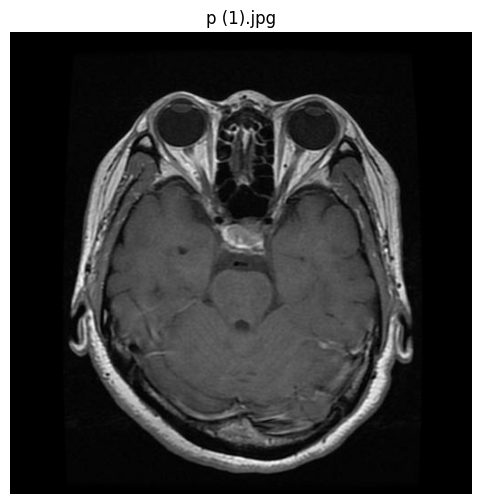

In [ ]:
import cv2
import os

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

if len(X) > 0 and X[0] is not None:
    img = X[0]
    # If BGR (cv2), convert to RGB for correct colors
    try:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except Exception:
        img_rgb = img  # already grayscale/RGB
    plt.imshow(img_rgb, cmap='gray')
    plt.axis('off')
    plt.show()
else:
    candidates = [
        pth,
        no_tumor_topath,
        no_tumor_frompath,
        os.path.join(dirct, 'Brain Tumor Data', 'Training', 'pituitary_tumor'),
        os.path.join(dirct, 'Brain Tumor Data', 'Training', 'no_tumor'),
        os.path.join(dirct, 'Training', 'pituitary_tumor'),
        os.path.join(dirct, 'Training', 'no_tumor'),
    ]
    shown = False
    for d in candidates:
        if not d:
            continue
        if os.path.isdir(d):
            for fname in os.listdir(d):
                fp = os.path.join(d, fname)
                if not os.path.isfile(fp):
                    continue
                img = cv2.imread(fp)
                if img is None:
                    continue
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.imshow(img_rgb)
                plt.title(os.path.basename(fp))
                plt.axis('off')
                plt.show()
                shown = True
                break
        if shown:
            break
    if not shown:
        print("No images found to display. Check that augmentation/training folders contain images.")

In [37]:
import cv2
from pathlib import Path


def load_image_folder(root_dir):
    images = []
    labels = []
    for cls, label in classes.items():
        class_dir = Path(root_dir) / cls
        if not class_dir.is_dir():
            continue
        for file_path in class_dir.iterdir():
            if not file_path.is_file():
                continue
            img = cv2.imread(str(file_path))
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            images.append(img)
            labels.append(label)
    return np.asarray(images), np.asarray(labels)


train_root = Path(dirct) / "Training"
test_root = Path(dirct) / "Testing"

X, Y = load_image_folder(train_root)
x_test, y_test = load_image_folder(test_root)

if X.shape[0] == 0 or Y.shape[0] == 0:
    raise ValueError("No training samples found under Brain_Tumor_Data/Training.")
if x_test.shape[0] == 0 or y_test.shape[0] == 0:
    raise ValueError("No test samples found under Brain_Tumor_Data/Testing.")

In [38]:
from tensorflow.keras.utils import to_categorical

x_train, x_val, y_train_raw, y_val_raw = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.20,
    stratify=Y,
)

y_train = to_categorical(y_train_raw, num_classes=2)
y_val = to_categorical(y_val_raw, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

x_train = np.array(x_train, dtype="float32") / 255.0
x_val = np.array(x_val, dtype="float32") / 255.0
x_test = np.array(x_test, dtype="float32") / 255.0

print("x_train Shape: ", x_train.shape)
print("x_val Shape: ", x_val.shape)
print("x_test Shape: ", x_test.shape)
print("y_train Shape: ", y_train.shape)
print("y_val Shape: ", y_val.shape)
print("y_test Shape: ", y_test.shape)

x_train Shape:  (977, 224, 224, 3)
x_val Shape:  (245, 224, 224, 3)
x_test Shape:  (179, 224, 224, 3)
y_train Shape:  (977, 2)
y_val Shape:  (245, 2)
y_test Shape:  (179, 2)


In [39]:
from tensorflow.keras.applications import vgg16

img_rows, img_cols = 224, 224

vgg = vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(img_rows, img_cols, 3))

In [ ]:
for layer in vgg.layers:
  layer.trainable=False

In [41]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

def lw(bottom_model, num_classes):
  top_model = bottom_model.output
  top_model = GlobalAveragePooling2D()(top_model)
  top_model = Dense(1024, activation='relu')(top_model)
  top_model = Dense(1024, activation='relu')(top_model)
  top_model = Dense(512, activation='relu')(top_model)
  top_model = Dense(num_classes, activation='softmax')(top_model)
  return top_model

In [42]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, Conv2D, MaxPooling2D, ZeroPadding2D

In [ ]:
import tempfile
from tensorflow.keras.models import load_model, save_model

def make_keras_picklable():
    def __getstate__(self):
        model_str = ""
        with tempfile.NamedTemporaryFile(suffix='.hdf5', delete=True) as fd:
            save_model(self, fd.name, overwrite=True)
            model_str = fd.read()
        d = {'model_str': model_str}
        return d

    def __setstate__(self, state):
        with tempfile.NamedTemporaryFile(suffix='.hdf5', delete=True) as fd:
            fd.write(state['model_str'])
            fd.flush()
            model = load_model(fd.name)
        self.__dict__ = model.__dict__

    from tensorflow.keras.models import Model
    cls = Model
    cls.__getstate__ = __getstate__
    cls.__setstate__ = __setstate__

In [ ]:
make_keras_picklable()

In [45]:
num_classes=2
FC_Head=lw(vgg,num_classes)
model=Model(inputs=vgg.input,outputs=FC_Head)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 16,815,426 (64.15 MB)

 Trainable params: 2,100,738 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [46]:
from tensorflow.keras.models import Model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# history = model.fit(
#     x_train,
#     y_train,
#     epochs=5,
#     validation_data=(x_val, y_val),
#     verbose=1,
#     initial_epoch=0,
# )

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 424s 14s/step - accuracy: 0.7533 - loss: 0.5369 - val_accuracy: 0.8898 - val_loss: 0.2462
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 421s 14s/step - accuracy: 0.9314 - loss: 0.1789 - val_accuracy: 0.8367 - val_loss: 0.5766
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 376s 12s/step - accuracy: 0.9580 - loss: 0.1070 - val_accuracy: 0.9796 - val_loss: 0.0616
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 351s 11s/step - accuracy: 0.9754 - loss: 0.0793 - val_accuracy: 0.9592 - val_loss: 0.1005
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 329s 10s/step - accuracy: 0.9826 - loss: 0.0474 - val_accuracy: 0.9918 - val_loss: 0.0279


In [48]:
# Save model
model.save("model_complete.keras")

from tensorflow.keras.models import model_from_json
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("model.weights.h5")

In [49]:
import tensorflow as tf

# Load the model 
try:
    loaded_model = tf.keras.models.load_model("model_complete.keras")
except:
    
    from tensorflow.keras.models import model_from_json
    json_file = open('model.json', 'r')
    loaded_model_json = json_file.read()
    json_file.close()
    loaded_model = model_from_json(loaded_model_json)
    loaded_model.load_weights("model.h5")

In [50]:
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.4360
Test accuracy: 0.8659


In [51]:
dec= {0: 'No Tumor', 1:'Positive Tumor'}

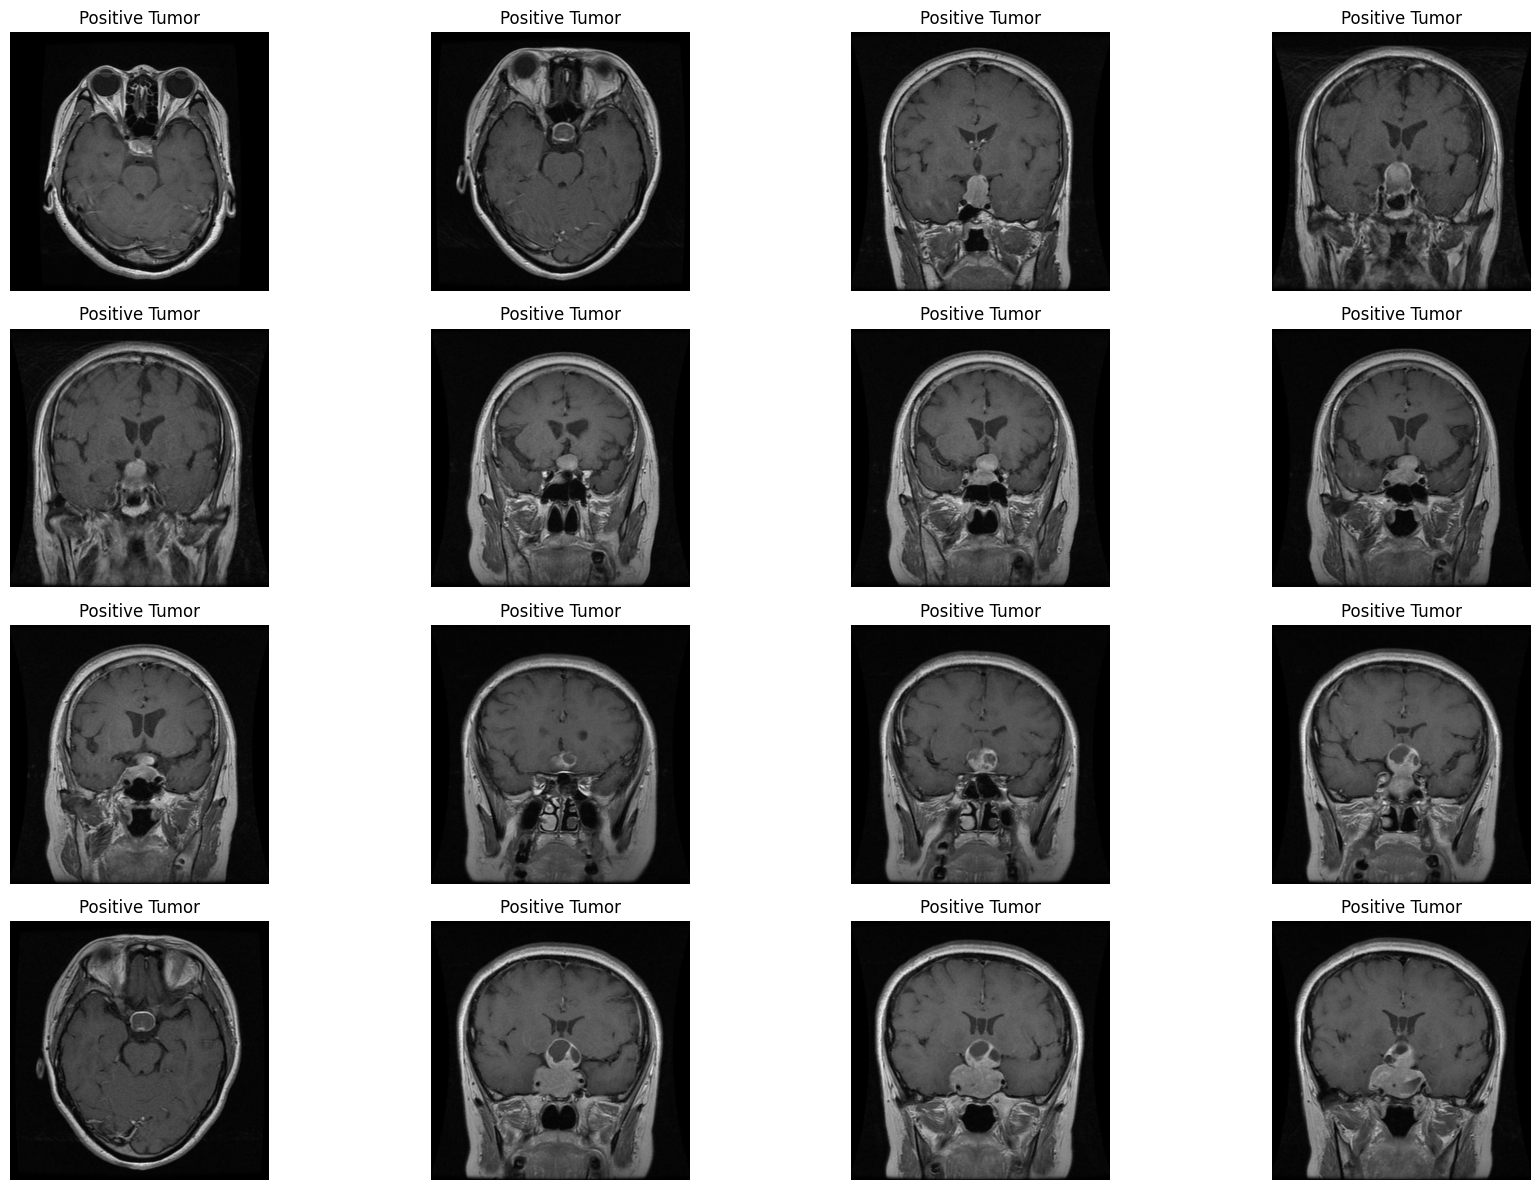

In [52]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np

plt.figure(figsize=(18,12))
pituitary_path = dirct + '/Training/pituitary_tumor'
c = 1
for i in os.listdir(pituitary_path)[:16]:
  plt.subplot(4, 4, c)
  img = cv2.imread(os.path.join(pituitary_path, i))
  if img is not None:
    img1 = cv2.resize(img, (224, 224)).astype("float32") / 255.0
    p = loaded_model.predict(np.array([img1]), verbose=0)
    result = np.argmax(p[0])
    plt.title(dec[result])
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    c += 1
plt.tight_layout()
plt.show()

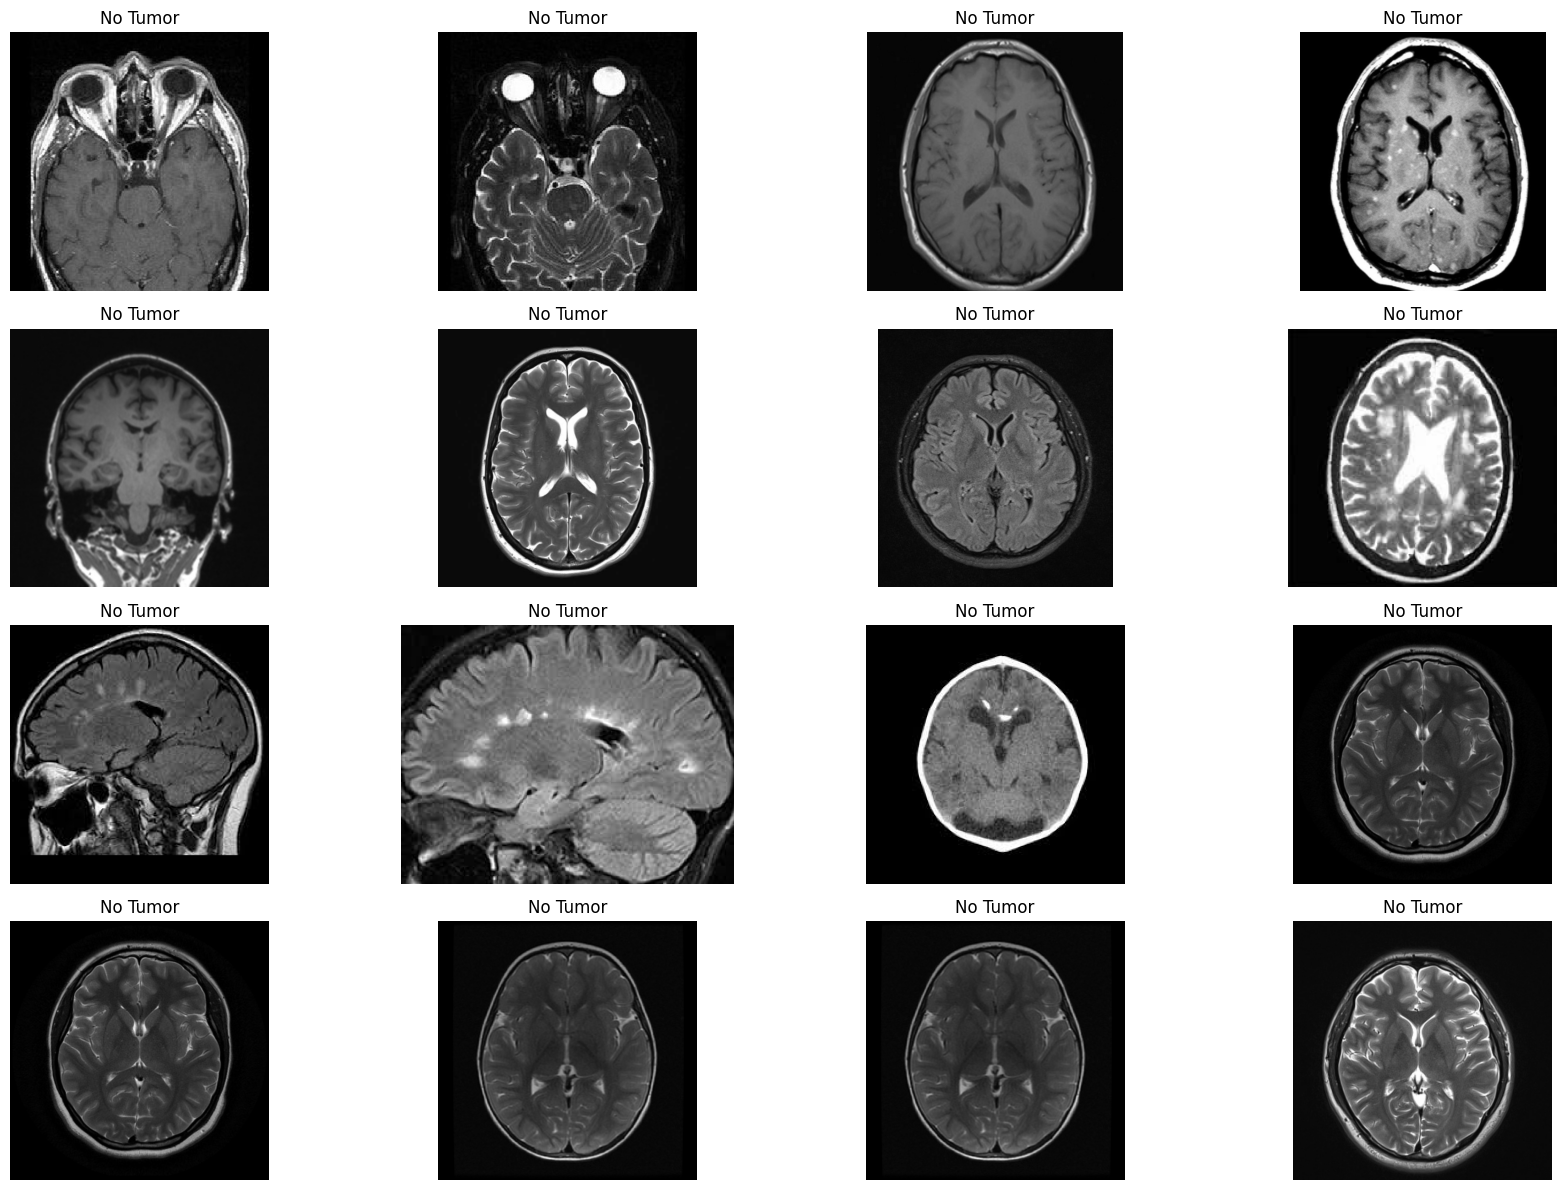

In [53]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np

plt.figure(figsize=(18, 12))
no_tumor_path = dirct + '/Training/no_tumor'
c = 1
for i in os.listdir(no_tumor_path)[:16]:
  plt.subplot(4, 4, c)
  img = cv2.imread(os.path.join(no_tumor_path, i))
  if img is not None:
    img1 = cv2.resize(img, (224, 224)).astype("float32") / 255.0
    p = loaded_model.predict(np.array([img1]), verbose=0)
    result = np.argmax(p[0])
    plt.title(dec[result])
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    c += 1
plt.tight_layout()
plt.show()